## Historical trnd analysis, category-wise

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)
df.head()

,CPU,Mother Board,RAM,Storage,Video Card
2013-06-01,NaN,NaN,NaN,119.0,NaN
2013-07-01,NaN,NaN,NaN,0.0,NaN
2013-08-01,NaN,NaN,NaN,0.0,NaN
2013-09-01,NaN,NaN,NaN,0.0,NaN
2013-10-01,NaN,NaN,NaN,0.0,NaN


In [2]:
summary = df.agg(['mean', 'std', 'min', 'max', 'sum']).T
summary['growth_%'] = ((df.iloc[-6:].mean() - df.iloc[:6].mean()) / df.iloc[:6].mean() * 100)
summary

,mean,std,min,max,sum,growth_%
CPU,156.483871,178.724531,0.0,584.0,4851.0,NaN
Mother Board,92.903226,135.261809,0.0,557.0,2880.0,NaN
RAM,44.037037,84.022653,0.0,334.0,1189.0,NaN
Storage,91.537037,164.276425,0.0,870.0,4943.0,297.478992
Video Card,95.612903,108.023663,0.0,351.0,2964.0,NaN


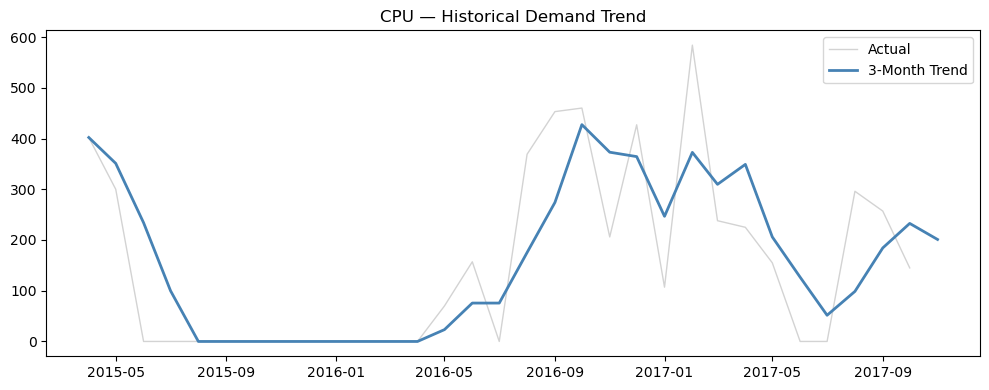

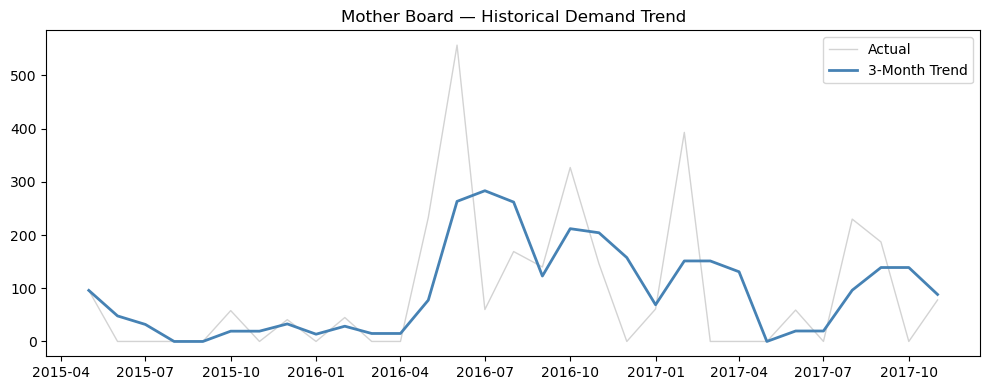

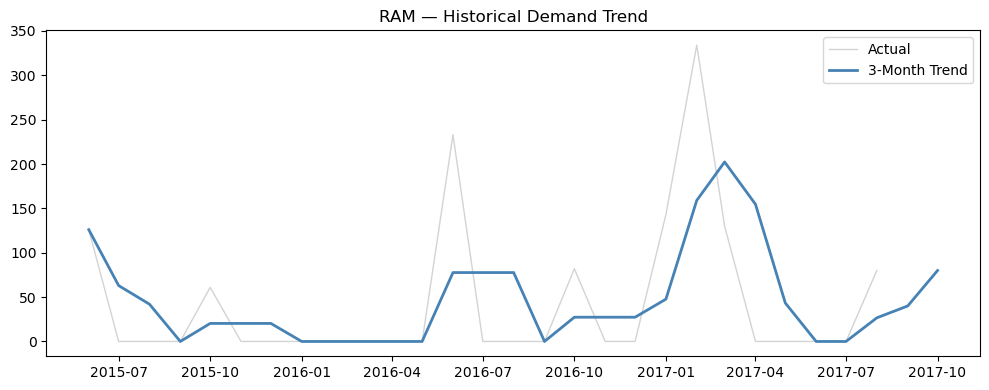

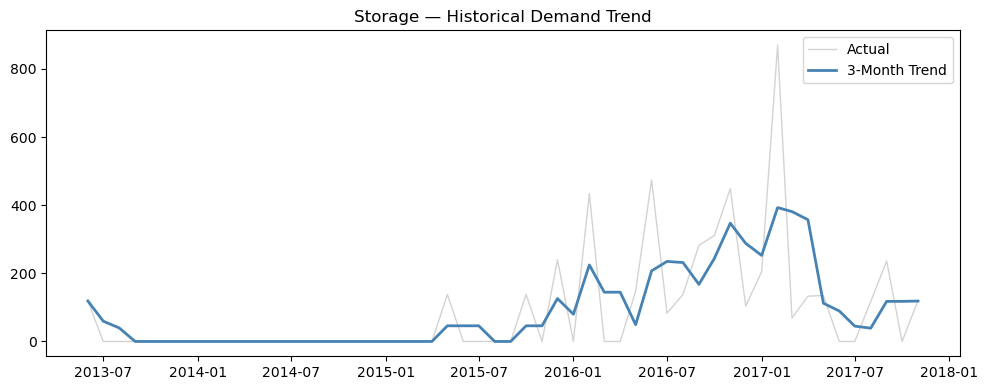

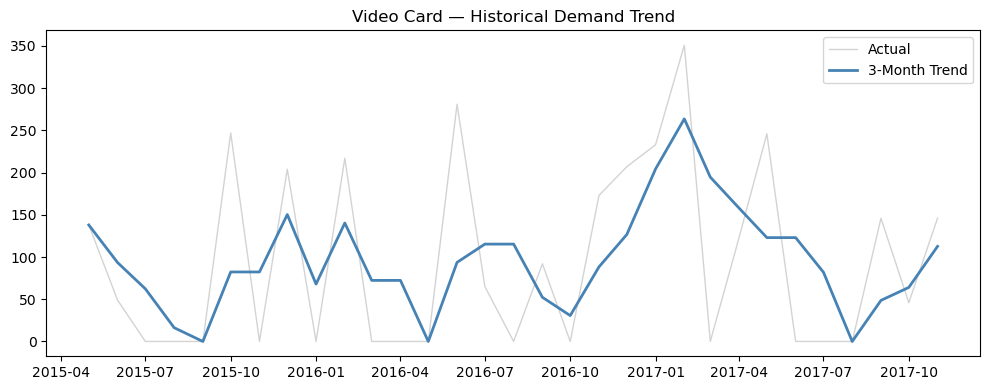

In [3]:
for cat in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df.index, df[cat], color='lightgray', label='Actual', linewidth=1)
    ax.plot(df.index, df[cat].rolling(3, min_periods=1).mean(), color='steelblue', label='3-Month Trend', linewidth=2)
    ax.set_title(f'{cat} — Historical Demand Trend')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Train/Test Split for Time-Series Visualization

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)

n = len(df)
test_size = int(n * 0.2)          # 20% held out for testing
split_idx = n - test_size
split_date = df.index[split_idx]

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

print(f"Split date: {split_date.date()}")
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Split date: 2017-02-01
Train shape: (44, 5), Test shape: (10, 5)


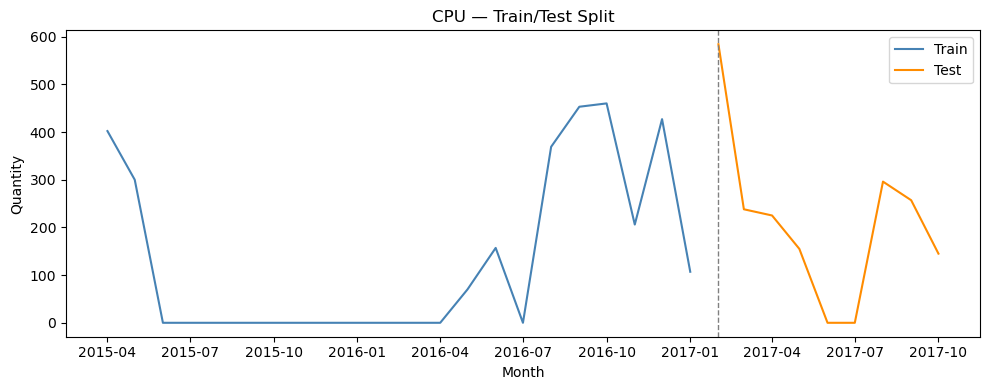

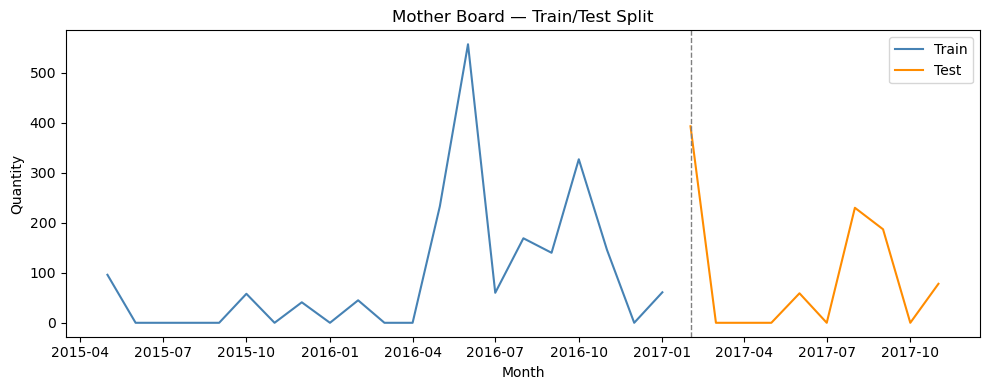

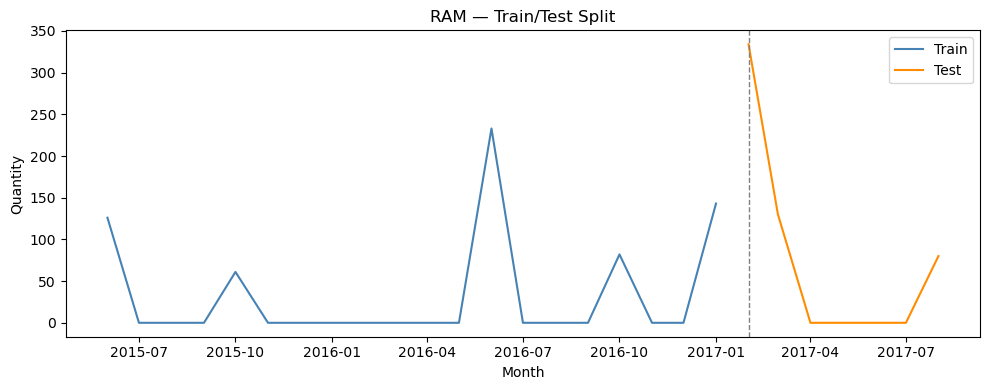

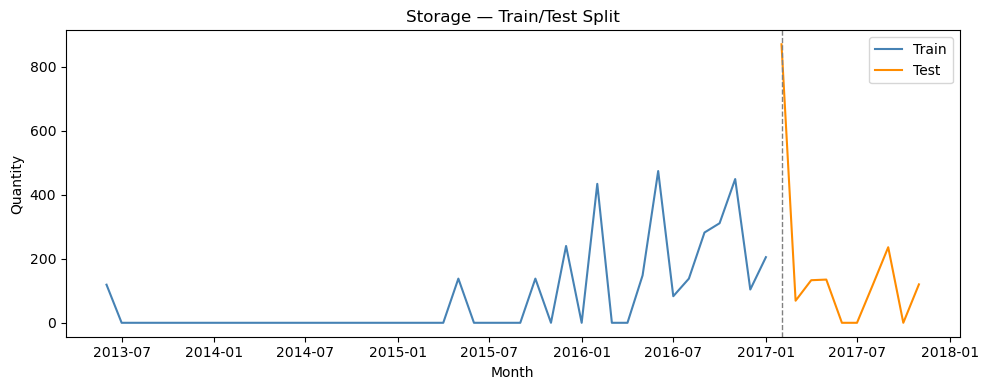

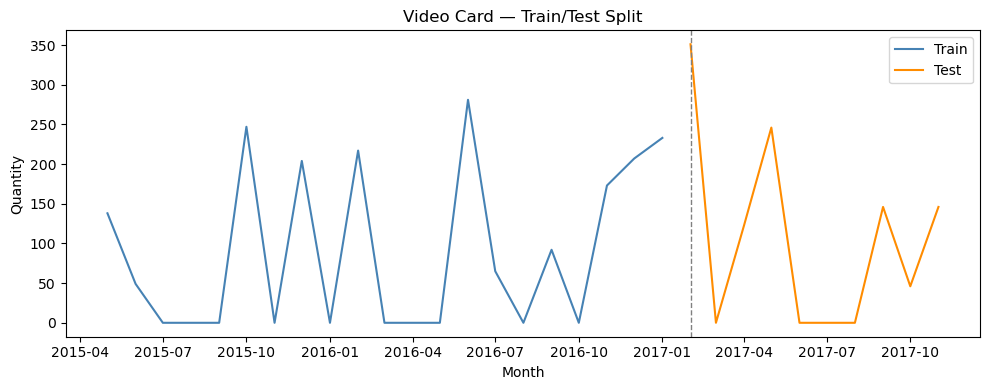

In [5]:
for cat in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train.index, train[cat], color='steelblue', label='Train', linewidth=1.5)
    ax.plot(test.index, test[cat], color='darkorange', label='Test', linewidth=1.5)
    ax.axvline(split_date, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{cat} — Train/Test Split')
    ax.set_xlabel('Month')
    ax.set_ylabel('Quantity')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [6]:
import os
os.makedirs('figures', exist_ok=True)

for cat in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(train.index, train[cat], color='steelblue', label='Train', linewidth=1.5)
    ax.plot(test.index, test[cat], color='darkorange', label='Test', linewidth=1.5)
    ax.axvline(split_date, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{cat} — Train/Test Split')
    ax.legend()
    fig.tight_layout()
    safe_name = cat.lower().replace(' ', '_')
    fig.savefig(f'figures/{safe_name}_train_test.png', dpi=150)
    plt.close(fig)

print(os.listdir('figures'))

['cpu_train_test.png', 'cpu_trend.png', 'monthly_demand_overview.png', 'mother_board_train_test.png', 'mother_board_trend.png', 'ram_train_test.png', 'ram_trend.png', 'storage_train_test.png', 'storage_trend.png', 'video_card_train_test.png', 'video_card_trend.png']


In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)

n = len(df)
test_size = int(n * 0.2)
split_idx = n - test_size
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

window = 3   # 3-month moving average — same idea as your Day 24 trend line

baseline_forecast = {}
for cat in df.columns:
    history = train[cat].copy()
    preds = []
    for actual_value in test[cat]:
        pred = history.tail(window).mean()   # avg of last 3 known months
        preds.append(pred)
        history = pd.concat([history, pd.Series([actual_value])])   # "actual" becomes known for next step
    baseline_forecast[cat] = preds

baseline_df = pd.DataFrame(baseline_forecast, index=test.index)
baseline_df.head()

,CPU,Mother Board,RAM,Storage,Video Card
2017-02-01,246.666667,69.000000,47.666667,252.666667,204.333333
2017-03-01,372.666667,151.333333,159.000000,393.000000,263.666667
2017-04-01,309.666667,151.333333,202.333333,381.333333,194.666667
2017-05-01,349.000000,131.000000,154.666667,357.333333,158.000000
2017-06-01,206.000000,0.000000,43.333333,112.333333,123.000000


In [15]:
error_summary = {}
for cat in df.columns:
    valid = test[cat].notna()   # only compare where actual data exists
    mae = np.mean(np.abs(test[cat][valid].values - baseline_df[cat][valid].values))
    error_summary[cat] = round(mae, 1)

error_df = pd.Series(error_summary, name='MAE').sort_values(ascending=False)
print(error_df)

Storage         200.3
CPU             169.5
Mother Board    133.7
RAM             113.7
Video Card      112.9
Name: MAE, dtype: float64


Storage         200.3
CPU             169.5
Mother Board    133.7
RAM             113.7
Video Card      112.9
Name: MAE, dtype: float64


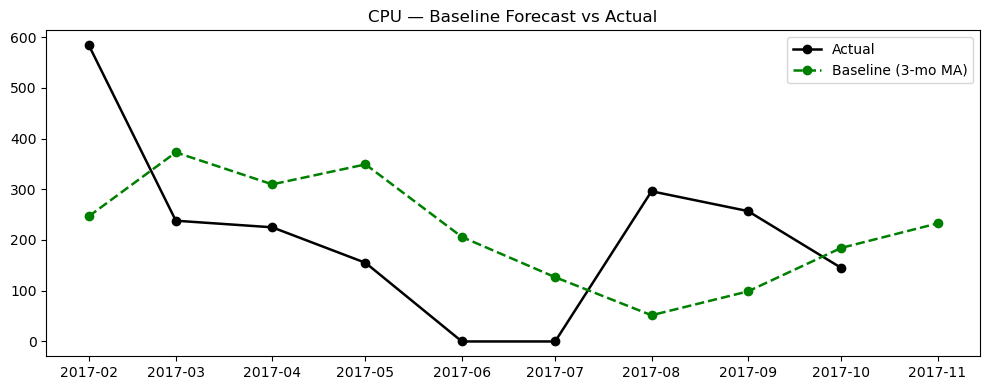

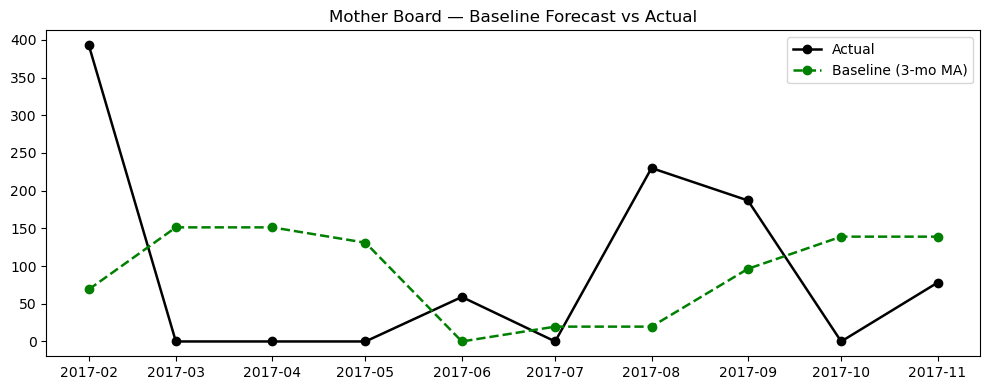

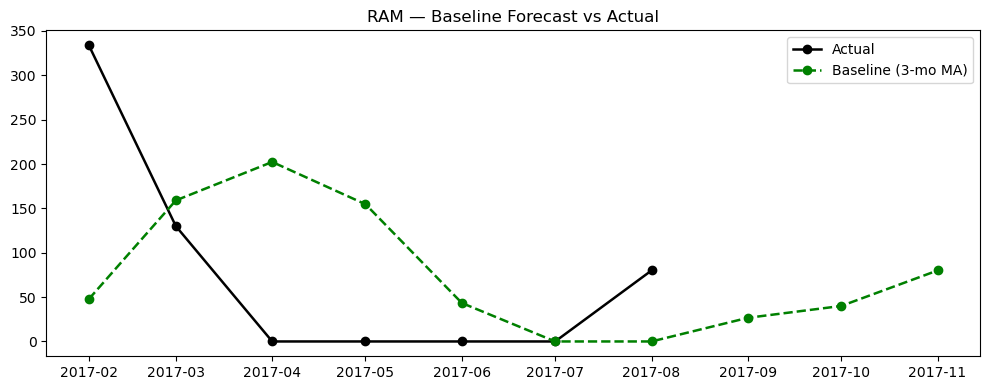

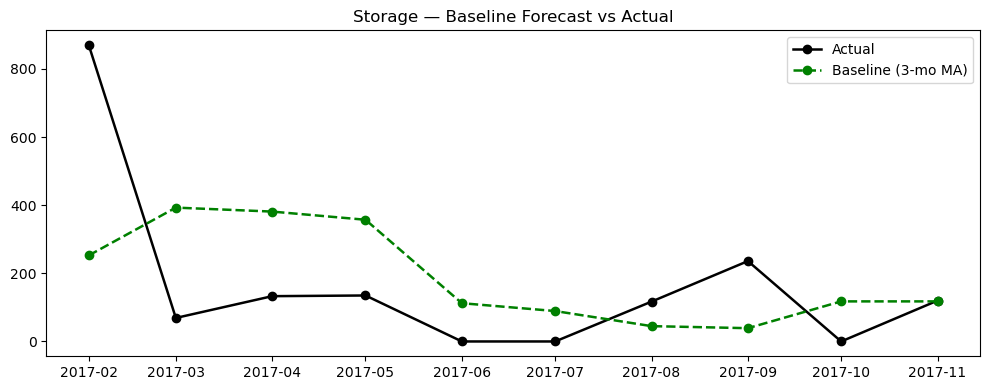

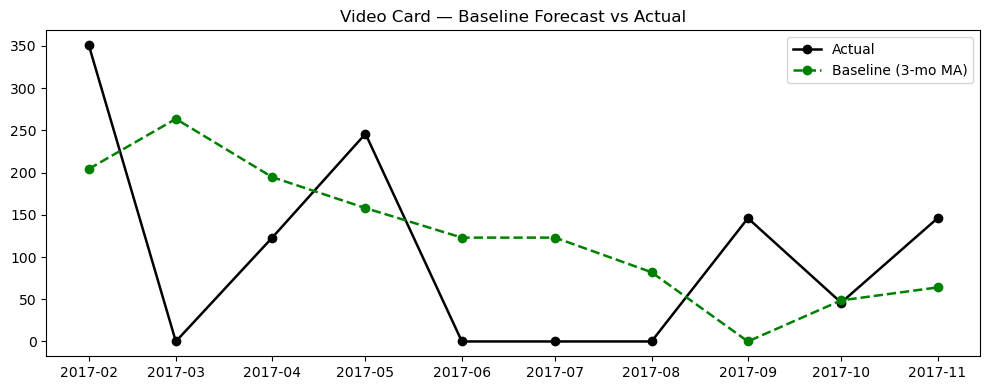

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)

n = len(df)
test_size = int(n * 0.2)
split_idx = n - test_size
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

# Walk-forward 3-month moving average baseline
window = 3
baseline_forecast = {}
for cat in df.columns:
    history = train[cat].copy()
    preds = []
    for actual_value in test[cat]:
        pred = history.tail(window).mean()
        preds.append(pred)
        history = pd.concat([history, pd.Series([actual_value])])
    baseline_forecast[cat] = preds

baseline_df = pd.DataFrame(baseline_forecast, index=test.index)

# MAE, skipping months with missing actual data
error_summary = {}
for cat in df.columns:
    valid = test[cat].notna()
    mae = np.mean(np.abs(test[cat][valid].values - baseline_df[cat][valid].values))
    error_summary[cat] = round(mae, 1)

error_df = pd.Series(error_summary, name='MAE').sort_values(ascending=False)
print(error_df)

# Plot + save each category
os.makedirs('figures', exist_ok=True)
for cat in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(test.index, test[cat], color='black', label='Actual', linewidth=1.8, marker='o')
    ax.plot(test.index, baseline_df[cat], color='green', linestyle='--', label='Baseline (3-mo MA)', linewidth=1.8, marker='o')
    ax.set_title(f'{cat} — Baseline Forecast vs Actual')
    ax.legend()
    plt.tight_layout()
    safe_name = cat.lower().replace(' ', '_')
    fig.savefig(f'figures/{safe_name}_baseline.png', dpi=150)
    plt.show()